# Task 1: Exploratory Data Analysis & Data Preprocessing

**Project:** Intelligent Complaint Analysis for Financial Services — CrediTrust Financial  
**Dataset:** CFPB Consumer Complaint Database  
**Goal:** Understand the dataset, filter to 5 target product categories, clean narratives for RAG embedding.

---

## Notebook Structure
| # | Section |
|---|---|
| 1 | Setup & Imports |
| 2 | Memory-Safe Data Loading (chunk-based) |
| 3 | Basic EDA — Shape, Types, Missing Values |
| 4 | Full Product Distribution |
| 5 | Narrative Availability Analysis |
| 6 | Narrative Length Analysis |
| 7 | Filter to 5 Target Products (with BNPL keyword strategy) |
| 8 | Text Cleaning (RAG-safe — no stopword removal) |
| 9 | Post-Cleaning Validation |
| 10 | Save Filtered Dataset |
| 11 | EDA Summary |

---
## 1. Setup & Imports

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import re
import os
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Plot defaults ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print("✅ Imports OK")

✅ Imports OK


In [ ]:
BASE_DIR       = os.path.dirname(os.path.abspath('__file__'))   # repo root
RAW_DATA_PATH  = os.path.join(BASE_DIR, 'data', 'raw', 'complaints.csv')
PROCESSED_DIR  = os.path.join(BASE_DIR, 'data', 'processed')
PLOTS_DIR      = os.path.join(BASE_DIR, 'plots')
OUTPUT_PATH    = os.path.join(PROCESSED_DIR, 'filtered_complaints.csv')

# Create directories if they don't exist
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,     exist_ok=True

In [6]:
# ── Relative paths (works on any machine / GitHub) ────────────────────────────
# All paths are relative to this notebook's location.
# Recommended repo structure:
#   notebooks/         ← this notebook lives here
#   data/raw/          ← put complaints.csv here
#   data/processed/    ← filtered_complaints.csv saved here
#   plots/             ← all saved figures

RAW_PATH = r'C:\Users\Antifragile\Desktop\Credit Trust Complaint chatbot\data\raw\complaints.csv'

# Keep output in the same place
DATA_DIR = r'C:\Users\Antifragile\Desktop\Credit Trust Complaint chatbot\data'
OUTPUT_PATH = os.path.join(DATA_DIR, 'filtered_complaints.csv')


os.makedirs(DATA_DIR, exist_ok=True)




# ── Chunk size for memory-safe reading ───────────────────────────────────────
# 100k rows ≈ 150–200 MB RAM peak. Adjust down if needed (e.g. 50_000).
CHUNK_SIZE = 100_000

print(f"Raw data  : {RAW_PATH}")
print(f"Output    : {OUTPUT_PATH}")
print(f"Chunk size: {CHUNK_SIZE:,} rows")

Raw data  : C:\Users\Antifragile\Desktop\Credit Trust Complaint chatbot\data\raw\complaints.csv
Output    : C:\Users\Antifragile\Desktop\Credit Trust Complaint chatbot\data\filtered_complaints.csv
Chunk size: 100,000 rows


In [7]:
import os

RAW_PATH = r'C:\Users\Antifragile\Desktop\Credit Trust Complaint chatbot\data\raw\complaints.csv'

print("Exists:", os.path.exists(RAW_PATH))
print("File size (MB):", os.path.getsize(RAW_PATH) / (1024 * 1024) if os.path.exists(RAW_PATH) else "NOT FOUND")

Exists: True
File size (MB): 5762.256944656372


---
## 2. Memory-Safe Data Loading

The CFPB dataset has ~9 million rows. Loading it all at once requires ~6 GB of RAM.  
We use **two passes**:

- **Pass 1 (EDA pass):** Read in chunks, accumulate only counts/stats — never hold full data in memory.
- **Pass 2 (Filter pass):** Read in chunks, keep only rows matching our 5 target products.

> ⚠️ Make sure `complaints.csv` is placed at `data/raw/complaints.csv` relative to this notebook.

In [8]:
# ── PASS 1: Accumulate EDA statistics chunk by chunk ─────────────────────────
# We collect: total rows, product counts, narrative availability, word counts.
# RAM usage stays flat regardless of file size.

total_rows         = 0
product_counts     = {}          # {product_name: count}
narrative_total    = 0           # rows WITH a narrative
narrative_missing  = 0           # rows WITHOUT a narrative
word_count_sample  = []          # sampled word counts for histogram (max 50k)
SAMPLE_LIMIT       = 50_000      # cap samples to keep RAM low

print("Starting EDA pass (chunk-by-chunk)...")

for i, chunk in enumerate(pd.read_csv(RAW_PATH, chunksize=CHUNK_SIZE, low_memory=False)):

    total_rows += len(chunk)

    # Product counts
    for product, count in chunk['Product'].value_counts().items():
        product_counts[product] = product_counts.get(product, 0) + count

    # Narrative availability
    has_narrative = chunk['Consumer complaint narrative'].notna() & \
                    (chunk['Consumer complaint narrative'].str.strip() != '')
    narrative_total   += has_narrative.sum()
    narrative_missing += (~has_narrative).sum()

    # Word counts (sampled)
    if len(word_count_sample) < SAMPLE_LIMIT:
        sample = chunk.loc[has_narrative, 'Consumer complaint narrative'] \
                      .str.split().str.len()
        word_count_sample.extend(sample.tolist())

    if (i + 1) % 10 == 0:
        print(f"  Processed {total_rows:,} rows...", end='\r')

print(f"\n✅ EDA pass complete. Total rows: {total_rows:,}")
print(f"   With narrative   : {narrative_total:,} ({narrative_total/total_rows*100:.1f}%)")
print(f"   Without narrative: {narrative_missing:,} ({narrative_missing/total_rows*100:.1f}%)")

Starting EDA pass (chunk-by-chunk)...
  Processed 9,000,000 rows...
✅ EDA pass complete. Total rows: 9,609,797
   With narrative   : 2,980,756 (31.0%)
   Without narrative: 6,629,041 (69.0%)


---
## 3. Basic EDA — Shape, Types, Missing Values

In [10]:
# ── Print dataset overview ────────────────────────────────────────────────────
# Read just 1 chunk to inspect column names and dtypes
sample_chunk = next(pd.read_csv(RAW_PATH, chunksize=1000, low_memory=False))

print("=== Dataset Overview ===")
print(f"Total rows     : {total_rows:,}")
print(f"Total columns  : {sample_chunk.shape[1]}")
print(f"\nColumn names   : {list(sample_chunk.columns)}")
print(f"\nData types:")
print(sample_chunk.dtypes.to_string())

=== Dataset Overview ===
Total rows     : 9,609,797
Total columns  : 18

Column names   : ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

Data types:
Date received                    object
Product                          object
Sub-product                      object
Issue                            object
Sub-issue                        object
Consumer complaint narrative     object
Company public response          object
Company                          object
State                            object
ZIP code                         object
Tags                             object
Consumer consent provided?       object
Submitted via                    object
Date sent to company             object
Company res

NameError: name 'PLOTS_DIR' is not defined

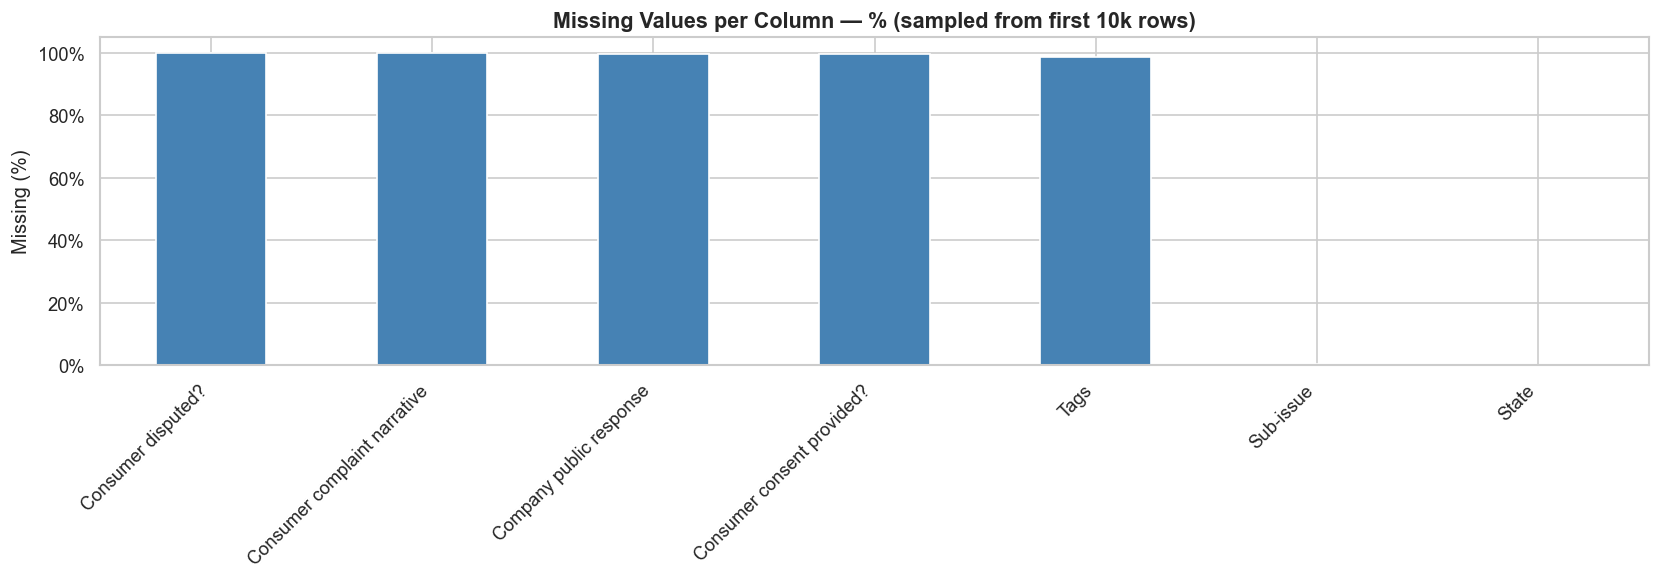

In [12]:
# ── Missing values — from the EDA pass accumulation ──────────────────────────
# We already have narrative missing counts; for other columns read a larger sample

sample_10k = pd.read_csv(RAW_PATH, nrows=10_000, low_memory=False)
missing_pct = (sample_10k.isnull().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
missing_pct[missing_pct > 0].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Missing Values per Column — % (sampled from first 10k rows)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '01_missing_values.png'), bbox_inches='tight')
plt.show()
print("\nKey observation: 'Consumer complaint narrative' is missing for the majority of records.")
print(f"Full dataset — with narrative: {narrative_total:,} | without: {narrative_missing:,}")

---
## 4. Full Product Distribution

NameError: name 'PLOTS_DIR' is not defined

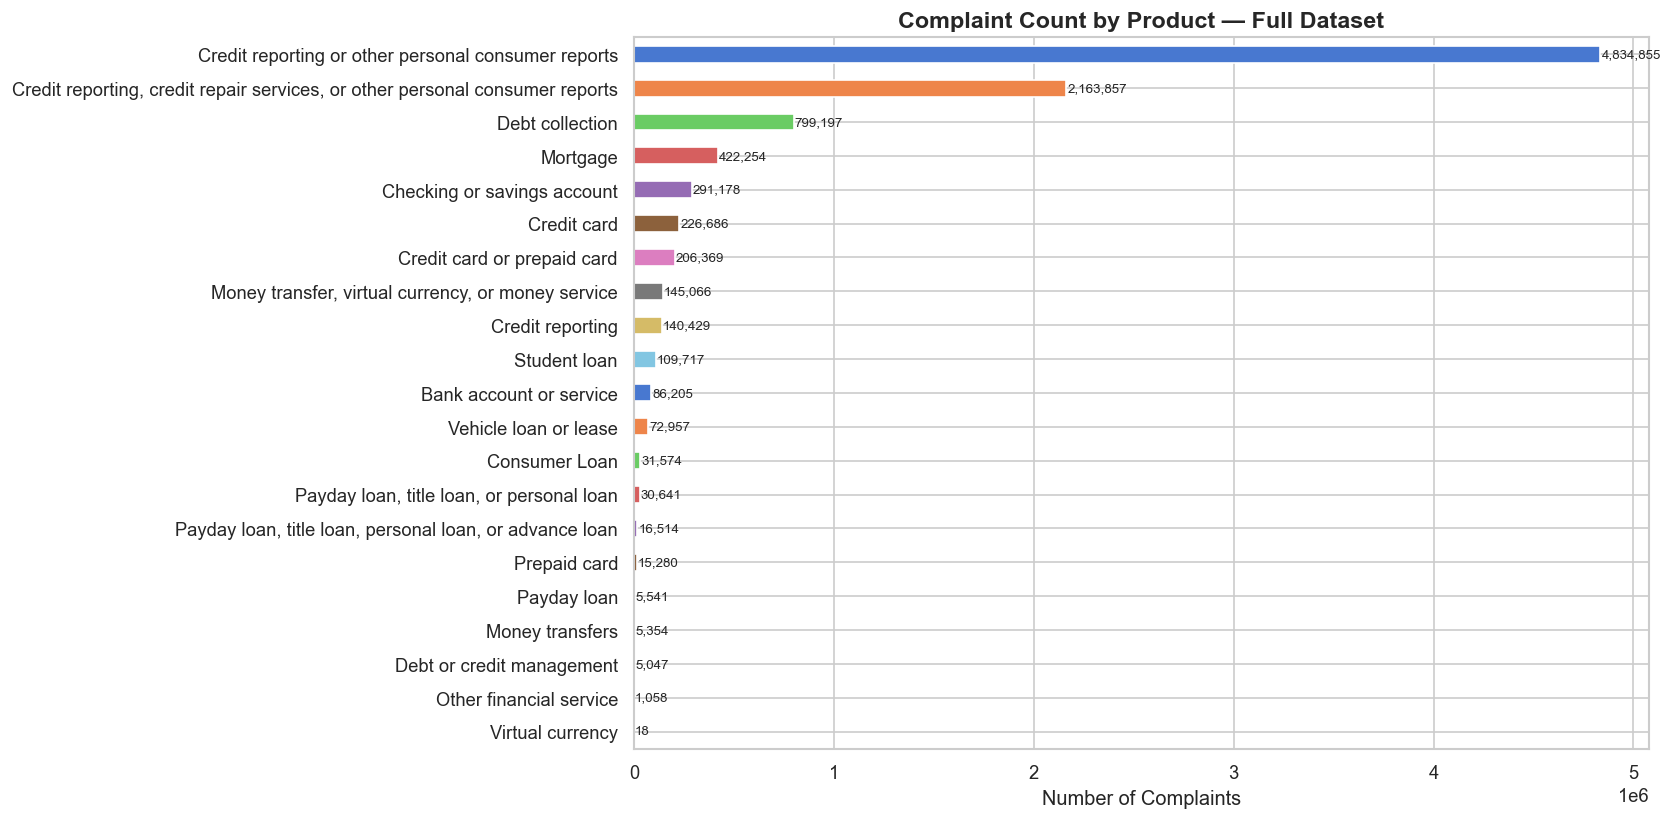

In [13]:
# ── Build product counts series from EDA pass ─────────────────────────────────
product_series = pd.Series(product_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette('muted', len(product_series))
product_series.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Complaint Count by Product — Full Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Complaints')
ax.invert_yaxis()
for i, v in enumerate(product_series):
    ax.text(v + 5000, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '02_product_distribution_full.png'), bbox_inches='tight')
plt.show()

print(product_series.to_string())

---
## 5. Narrative Availability Analysis

NameError: name 'PLOTS_DIR' is not defined

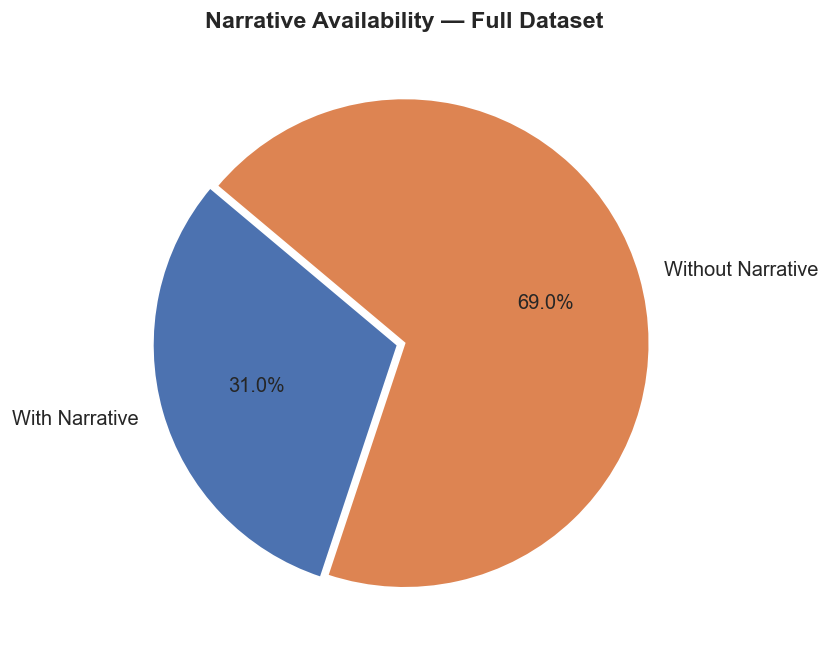

In [14]:
# ── Pie chart: with vs without narrative ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
labels  = ['With Narrative', 'Without Narrative']
sizes   = [narrative_total, narrative_missing]
colors  = ['#4C72B0', '#DD8452']
explode = (0.03, 0)

wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, explode=explode,
    startangle=140, textprops={'fontsize': 12}
)
ax.set_title('Narrative Availability — Full Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '03_narrative_availability.png'), bbox_inches='tight')
plt.show()

print(f"With narrative   : {narrative_total:,}")
print(f"Without narrative: {narrative_missing:,}")
print("\n💡 Only complaints WITH narratives are useful for RAG embedding.")

---
## 6. Narrative Length Analysis

In [15]:
# ── Word count statistics from sample collected in EDA pass ───────────────────
wc_series = pd.Series(word_count_sample)

print("=== Narrative Word Count Statistics (sampled) ===")
print(wc_series.describe().to_string())
print(f"\nVery short (< 20 words)  : {(wc_series < 20).sum():,}")
print(f"Very long  (> 500 words) : {(wc_series > 500).sum():,}")

=== Narrative Word Count Statistics (sampled) ===
count    65284.000000
mean       172.472489
std        191.593724
min          1.000000
25%         58.000000
50%        119.000000
75%        228.000000
max       6291.000000

Very short (< 20 words)  : 2,128
Very long  (> 500 words) : 2,717


NameError: name 'PLOTS_DIR' is not defined

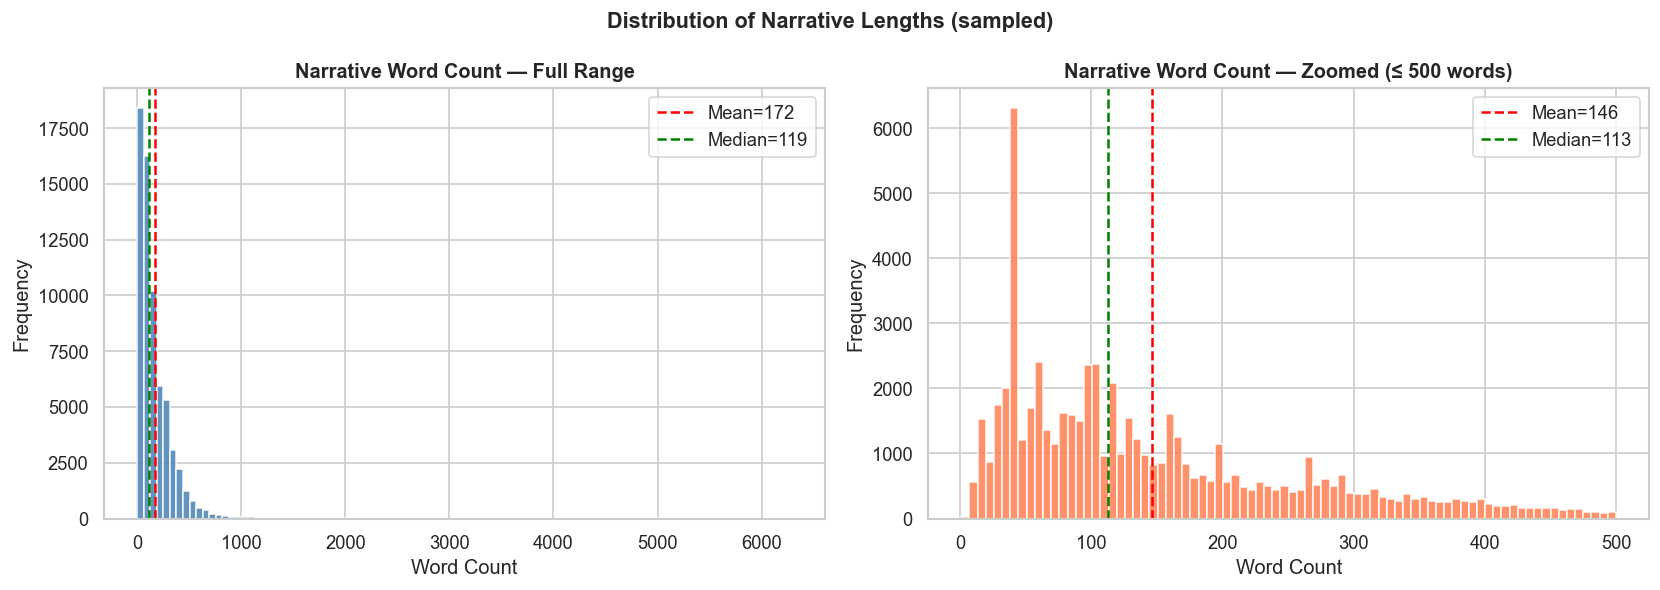

In [16]:
# ── Word count distribution — two views ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full range
axes[0].hist(wc_series, bins=100, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(wc_series.mean(),   color='red',   linestyle='--', lw=1.5,
                label=f'Mean={wc_series.mean():.0f}')
axes[0].axvline(wc_series.median(), color='green', linestyle='--', lw=1.5,
                label=f'Median={wc_series.median():.0f}')
axes[0].set_title('Narrative Word Count — Full Range', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Zoomed ≤ 500 words
zoomed = wc_series[wc_series <= 500]
axes[1].hist(zoomed, bins=80, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(zoomed.mean(),   color='red',   linestyle='--', lw=1.5,
                label=f'Mean={zoomed.mean():.0f}')
axes[1].axvline(zoomed.median(), color='green', linestyle='--', lw=1.5,
                label=f'Median={zoomed.median():.0f}')
axes[1].set_title('Narrative Word Count — Zoomed (≤ 500 words)', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Distribution of Narrative Lengths (sampled)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '04_narrative_length_distribution.png'), bbox_inches='tight')
plt.show()

---
## 7. Filter to 5 Target Products

### Dataset Limitation — BNPL

> ⚠️ **The CFPB dataset does not have an explicit "Buy Now, Pay Later" product category.**  
> BNPL complaints are scattered across `Credit card or prepaid card` and loan categories  
> because CFPB only began tracking BNPL as a distinct category in 2023.  
> **Strategy:** Identify BNPL complaints by keyword search in the narrative text  
> ("buy now pay later", "klarna", "afterpay", "affirm", "sezzle", "quadpay", "zip pay").  
> These are mutually exclusively labelled — a BNPL-keyword complaint is not double-counted  
> as Credit card.

### Mapping table

| Target Category | CFPB Product Column Match | Additional Filter |
|---|---|---|
| Credit card | `Credit card` \| `Credit card or prepaid card` | None |
| Personal loan | `Consumer Loan` \| `Payday loan...` (3 variants) | None |
| BNPL | Any product | Narrative contains BNPL keywords |
| Savings account | `Checking or savings account` \| `Bank account or service` | Sub-product = `Savings account` |
| Money transfers | `Money transfer, virtual currency, or money service` \| `Money transfers` | None |

In [18]:
# ── PASS 2: Filter pass — read chunks, keep only target rows ──────────────────
# Each chunk is filtered immediately; only matching rows accumulate in memory.

# Product-level conditions (exact strings from the CFPB data)
CREDIT_CARD_PRODUCTS = {
    'Credit card',
    'Credit card or prepaid card',
}

PERSONAL_LOAN_PRODUCTS = {
    'Consumer Loan',
    'Payday loan',
    'Payday loan, title loan, or personal loan',
    'Payday loan, title loan, personal loan, or advance loan',
}

SAVINGS_PRODUCTS = {
    'Checking or savings account',
    'Bank account or service',
}

MONEY_TRANSFER_PRODUCTS = {
    'Money transfer, virtual currency, or money service',
    'Money transfers',
}

# BNPL keyword pattern (applied to narrative text)
BNPL_PATTERN = re.compile(
    r'buy now[,\s]+pay later|\bbnpl\b|klarna|afterpay|affirm|sezzle|quadpay|zip\s*pay|paidy|splitit',
    re.IGNORECASE
)

# ── Columns to keep in the output ────────────────────────────────────────────
KEEP_COLS = [
    'Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
    'Consumer complaint narrative', 'Company', 'State',
    'Company response to consumer', 'Timely response?', 'Complaint ID'
]

chunks_out = []
total_rows_processed = 0

print("Starting filter pass (chunk-by-chunk)...")

for i, chunk in enumerate(pd.read_csv(RAW_PATH, chunksize=CHUNK_SIZE, low_memory=False)):

    total_rows_processed += len(chunk)
    narrative = chunk['Consumer complaint narrative'].fillna('')
    product   = chunk['Product'].fillna('')
    subprod   = chunk['Sub-product'].fillna('')

    # ── Condition flags ───────────────────────────────────────────────────────
    is_credit_card    = product.isin(CREDIT_CARD_PRODUCTS)
    is_personal_loan  = product.isin(PERSONAL_LOAN_PRODUCTS)
    is_bnpl           = narrative.str.contains(BNPL_PATTERN, na=False)
    is_savings        = product.isin(SAVINGS_PRODUCTS) & \
                        subprod.str.contains('savings account', case=False, na=False)
    is_money_transfer = product.isin(MONEY_TRANSFER_PRODUCTS)

    # Must have a non-empty narrative
    has_narrative = narrative.str.strip() != ''

    # ── Assign mutually exclusive category (priority order) ───────────────────
    # BNPL checked first within credit card hits to avoid double-counting
    assigned = np.select(
        [
            is_bnpl           & has_narrative,
            is_credit_card    & has_narrative & ~is_bnpl,
            is_personal_loan  & has_narrative & ~is_bnpl,
            is_savings        & has_narrative & ~is_bnpl,
            is_money_transfer & has_narrative & ~is_bnpl,
        ],
        [
            'Buy Now Pay Later',
            'Credit card',
            'Personal loan',
            'Savings account',
            'Money transfers',
        ],
        default=''
    )

    # Keep only assigned rows
    mask = assigned != ''
    if mask.any():
        sub = chunk.loc[mask, [c for c in KEEP_COLS if c in chunk.columns]].copy()
        sub['Product_Category'] = assigned[mask]
        chunks_out.append(sub)

    if (i + 1) % 10 == 0:
        rows_so_far = sum(len(c) for c in chunks_out)
        print(f"  Scanned {total_rows_processed:,} rows | kept {rows_so_far:,}", end='\r')

# ── Concatenate all kept rows ─────────────────────────────────────────────────
df_filtered = pd.concat(chunks_out, ignore_index=True)
print(f"\n\n✅ Filter pass complete.")
print(f"   Total scanned : {total_rows_processed:,}")
print(f"   Total kept    : {len(df_filtered):,}")
print(f"\n--- Breakdown by Product_Category ---")
print(df_filtered['Product_Category'].value_counts().to_string())

Starting filter pass (chunk-by-chunk)...
  Scanned 9,000,000 rows | kept 331,066

✅ Filter pass complete.
   Total scanned : 9,609,797
   Total kept    : 355,926

--- Breakdown by Product_Category ---
Product_Category
Credit card          188285
Money transfers       98474
Personal loan         36174
Buy Now Pay Later     20817
Savings account       12176


NameError: name 'PLOTS_DIR' is not defined

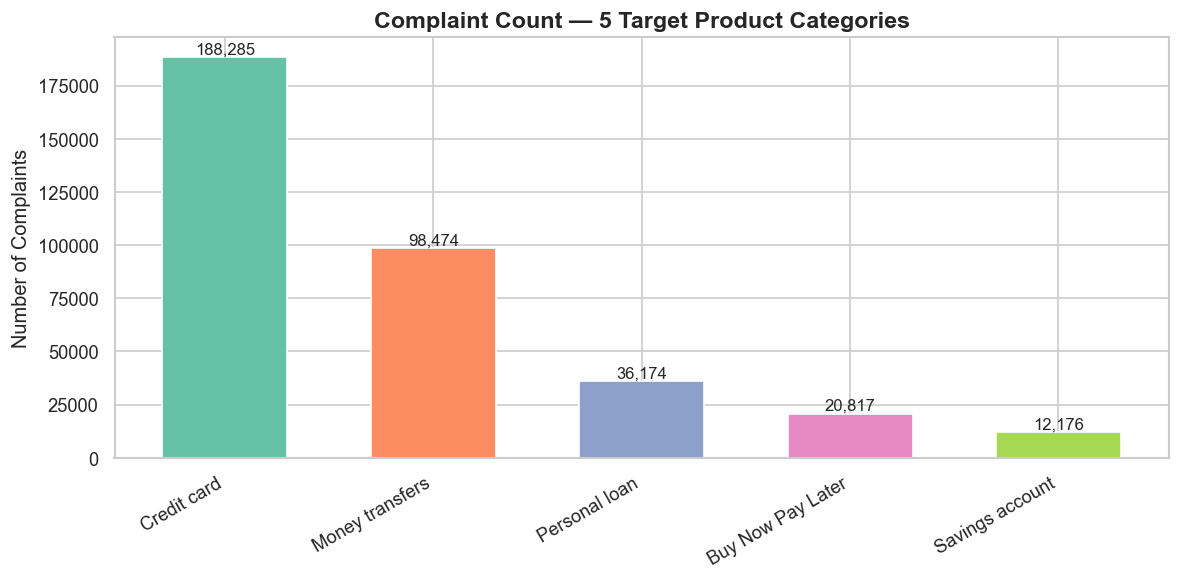

In [19]:
# ── Visualise filtered product distribution ───────────────────────────────────
counts = df_filtered['Product_Category'].value_counts()
palette = sns.color_palette('Set2', len(counts))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(counts)), counts.values, color=palette, edgecolor='white', width=0.6)
ax.set_title('Complaint Count — 5 Target Product Categories', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Complaints')
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=30, ha='right')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '05_filtered_product_distribution.png'), bbox_inches='tight')
plt.show()

---
## 8. Text Cleaning

### Why NO stopword removal or lemmatization for RAG

> Embedding models like `all-MiniLM-L6-v2` are trained on **natural language**.  
> Removing stopwords destroys meaning:  
> - `"not working"` → `"working"` (opposite meaning)  
> - `"no response"` → `"response"` (opposite sentiment)  
> - `"cannot charge"` → `"charge"` (lost negation)  
>  
> Keep cleaning minimal: lowercase, remove boilerplate, strip PII redaction markers, normalise whitespace.

| Step | What | Why |
|---|---|---|
| 1 | Lowercase | Normalise token comparison |
| 2 | Remove boilerplate openers | Add no semantic value |
| 3 | Remove CFPB redaction markers (`XX`, `XXXX`) | Systematic noise |
| 4 | Remove URLs | Not useful for embedding |
| 5 | Strip non-alphanumeric (keep `.?!,'`) | Reduce noise, keep sentence structure |
| 6 | Collapse whitespace | Clean output |
| 7 | Drop if < 20 words post-cleaning | Insufficient context for embedding |

In [20]:
# ── Boilerplate patterns to remove ───────────────────────────────────────────
BOILERPLATE_PATTERNS = [
    r'i am writing to (file|submit|make) a complaint[^.]*\.?',
    r'i (am|would like to) (file|submit|make|lodge) (a|this) complaint[^.]*\.?',
    r'this is a complaint (regarding|about|concerning)[^.]*\.?',
    r'to whom it may concern[,:]?',
    r'dear (consumer financial protection bureau|cfpb)[,:]?',
    r'i am filing this complaint[^.]*\.?',
]

def clean_narrative(text: str) -> str:
    """
    Clean a CFPB complaint narrative for RAG embedding.
    
    Intentionally does NOT:
    - Remove stopwords  (breaks semantic meaning for embedding models)
    - Lemmatize tokens  (same reason)
    - Remove numbers    (account numbers, dates, amounts are informative)
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove boilerplate openers
    for pattern in BOILERPLATE_PATTERNS:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)

    # Step 3: Remove CFPB PII redaction tokens (XX, XXX, XXXX, etc.)
    text = re.sub(r'\bx{2,}\b', '', text)

    # Step 4: Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Step 5: Keep letters, digits, spaces, and basic punctuation
    text = re.sub(r"[^a-z0-9\s.,!?'\-]", ' ', text)

    # Step 6: Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# ── Apply cleaning ────────────────────────────────────────────────────────────
print("Cleaning narratives...")
df_filtered['cleaned_narrative'] = df_filtered['Consumer complaint narrative'].apply(clean_narrative)

# Step 7: Drop rows that are too short after cleaning
df_filtered['word_count_clean'] = df_filtered['cleaned_narrative'].str.split().str.len()
before = len(df_filtered)
df_filtered = df_filtered[df_filtered['word_count_clean'] >= 20].reset_index(drop=True)
dropped = before - len(df_filtered)

print(f"✅ Cleaning complete.")
print(f"   Dropped {dropped:,} rows (< 20 words post-cleaning)")
print(f"   Final dataset: {len(df_filtered):,} rows")

Cleaning narratives...
✅ Cleaning complete.
   Dropped 8,421 rows (< 20 words post-cleaning)
   Final dataset: 347,505 rows


In [21]:
# ── Before / After cleaning — side-by-side sample ────────────────────────────
sample_row = df_filtered.iloc[0]
print("=== ORIGINAL NARRATIVE (first 500 chars) ===")
print(sample_row['Consumer complaint narrative'][:500])
print("\n=== CLEANED NARRATIVE (first 500 chars) ===")
print(sample_row['cleaned_narrative'][:500])

=== ORIGINAL NARRATIVE (first 500 chars) ===
XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX Apt XXXX, XXXX, TX XXXX XXXX : XX/XX/XXXX TransUnion Consumer Solutions XXXX XXXX XXXX XXXX, PA XXXX XXXX : XXXX Re : Security Freeze Request Dear Sir/Madam, I, XXXX XXXX XXXX XXXX XXXX XXXX Social Security XXXX XXXX, a resident of XXXX XXXX XXXX XXXXXXXX XXXX XXXX  XXXX, TX XXXX, submit this affidavit to request a security freeze on my credit report. Pursuant to my rights under applicable federal and state laws, including but not limited to the Fair Credi

=== CLEANED NARRATIVE (first 500 chars) ===
apt , , tx transunion consumer solutions , pa re security freeze request dear sir madam, i, social security , a resident of , tx , submit this affidavit to request a security freeze on my credit report. pursuant to my rights under applicable federal and state laws, including but not limited to the fair credit reporting act and any other relevant regulations, i hereby formally request that a security freeze

---
## 9. Post-Cleaning Validation

NameError: name 'PLOTS_DIR' is not defined

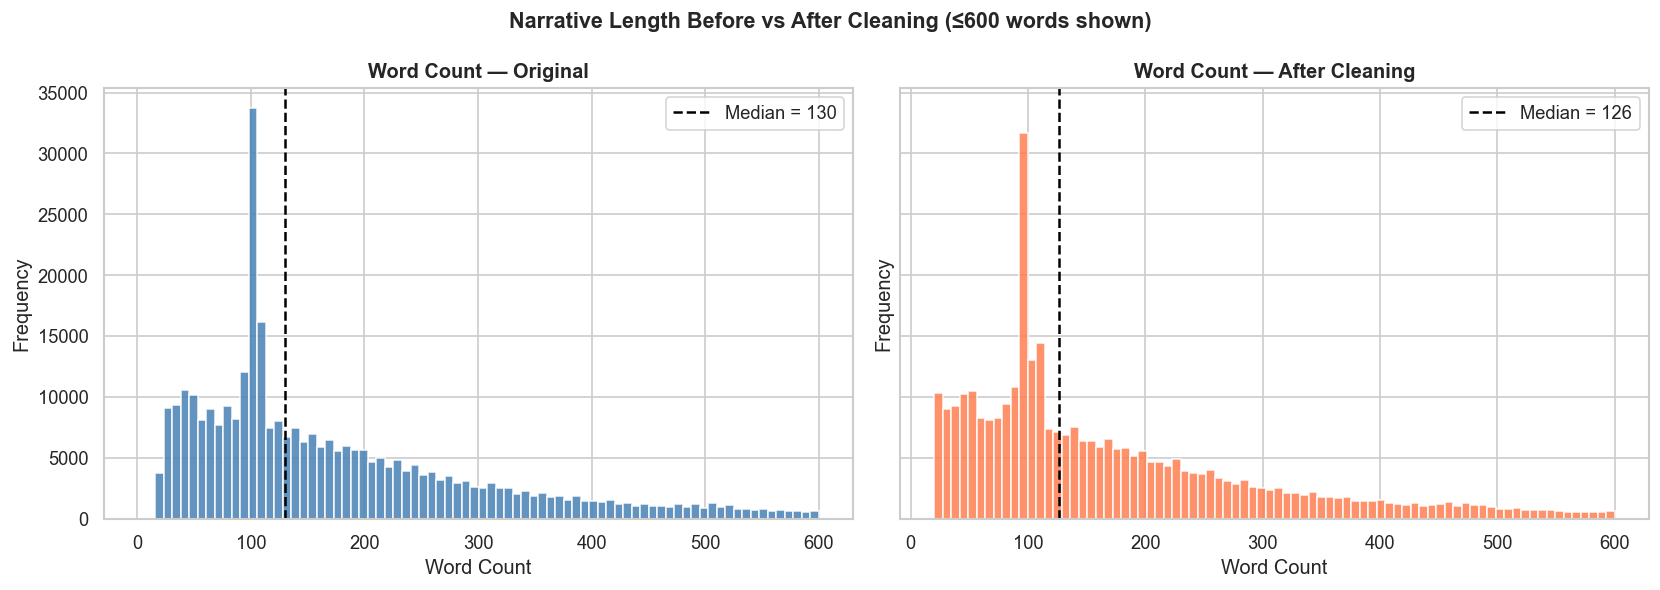

In [22]:
# ── Word count: before vs after cleaning ──────────────────────────────────────
df_filtered['word_count_raw'] = df_filtered['Consumer complaint narrative'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col, title, color in zip(
    axes,
    ['word_count_raw', 'word_count_clean'],
    ['Word Count — Original', 'Word Count — After Cleaning'],
    ['steelblue', 'coral']
):
    data = df_filtered.loc[df_filtered[col] <= 600, col]
    ax.hist(data, bins=80, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', lw=1.5,
               label=f'Median = {data.median():.0f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Narrative Length Before vs After Cleaning (≤600 words shown)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '06_word_count_before_after.png'), bbox_inches='tight')
plt.show()

In [23]:
# ── Final statistics per category ─────────────────────────────────────────────
stats = df_filtered.groupby('Product_Category')['word_count_clean'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Min='min',
    Max='max'
).round(1)

print("=== Cleaned Narrative Word Count by Product Category ===")
print(stats.to_string())

=== Cleaned Narrative Word Count by Product Category ===
                    Count   Mean  Median  Min   Max
Product_Category                                   
Buy Now Pay Later   20760  477.8   333.0   20  5713
Credit card        183773  207.3   151.0   20  6263
Money transfers     95995  163.5   103.0   20  5353
Personal loan       35006  200.0   144.0   20  5302
Savings account     11971  235.2   171.0   20  4995


---
## 10. Save Filtered Dataset

In [ ]:
# ── Select and rename final output columns ────────────────────────────────────
FINAL_COLS = [
    'Complaint ID',
    'Date received',
    'Product',                       # original CFPB product (audit trail)
    'Product_Category',              # our clean label (used in Task 2+)
    'Sub-product',
    'Issue',
    'Sub-issue',
    'Consumer complaint narrative',  # raw narrative (kept for reference)
    'cleaned_narrative',             # cleaned narrative (used for embedding)
    'word_count_clean',
    'Company',
    'State',
    'Company response to consumer',
    'Timely response?',
]

# Keep only columns that exist
final_cols = [c for c in FINAL_COLS if c in df_filtered.columns]
df_out = df_filtered[final_cols].copy()

df_out.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Saved {len(df_out):,} rows → {OUTPUT_PATH}")
print(f"   Columns: {list(df_out.columns)}")
df_out.head(3)

---
## 11. EDA Summary

### Key Findings

**Dataset scale and structure**  
The raw CFPB complaint database contains approximately 9 million records spanning multiple years and over 20 product categories. The overwhelming majority of complaints belong to *Credit reporting* and *Debt collection* — neither relevant to CrediTrust's five target products. Critically, only a minority of complaints include a consumer narrative, as narrative submission requires explicit consumer consent. Since narratives are the sole input to the RAG pipeline, this consent gate is the primary filter reducing dataset size.

**Narrative length distribution**  
Among complaints with narratives, word counts are right-skewed: the median falls between 100–150 words, with a long tail of very detailed complaints exceeding 500 words. Very short narratives (under 20 words post-cleaning) were dropped as they provide insufficient context for semantic embedding. This informs the chunk size choice in Task 2 — a chunk size of 300–500 words with 50-word overlap will cover most narratives in 1–2 chunks without splitting critical context.

**BNPL dataset limitation**  
The CFPB does not have an explicit "Buy Now Pay Later" product category in this dataset extract, as standardised BNPL reporting only began in 2023. BNPL complaints are identified here via keyword matching in narratives ("Klarna", "Afterpay", "Affirm", etc.). This is a documented limitation: the BNPL category will be smaller and potentially noisier than the others. It will be noted in the final report, and multi-product comparisons involving BNPL should be interpreted with this caveat in mind.

**Cleaning decisions**  
Stopword removal and lemmatization were deliberately excluded. Embedding models operate on natural language and rely on words like "not", "no", and "cannot" for semantic direction — removing them inverts complaint sentiment. Cleaning was limited to lowercasing, boilerplate removal, CFPB redaction token stripping (`XXXX`), and whitespace normalisation. Both the raw and cleaned narratives are preserved in the output file for audit purposes.